In [15]:
# Data processing tools
import pandas as pd
import numpy as np
from numpy import mean
from numpy import std
from math import sqrt
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import itertools
from collections import Counter
from sklearn.preprocessing import LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessign data
df = pd.read_csv('austinHousingData.csv')
df.head()

,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,...,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
0,111373431,pflugerville,14424 Lake Victor Dr,78660,"14424 Lake Victor Dr, Pflugerville, TX 78660 i...",30.430632,-97.663078,1.98,2,True,...,1,1,1.266667,2.666667,1063,14,3.0,4,2,111373431_ffce26843283d3365c11d81b8e6bdc6f-p_f...
1,120900430,pflugerville,1104 Strickling Dr,78660,Absolutely GORGEOUS 4 Bedroom home with 2 full...,30.432673,-97.661697,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,4,1,120900430_8255c127be8dcf0a1a18b7563d987088-p_f...
2,2084491383,pflugerville,1408 Fort Dessau Rd,78660,Under construction - estimated completion in A...,30.409748,-97.639771,1.98,0,True,...,1,1,1.200000,3.000000,1108,14,2.0,3,1,2084491383_a2ad649e1a7a098111dcea084a11c855-p_...
3,120901374,pflugerville,1025 Strickling Dr,78660,Absolutely darling one story home in charming ...,30.432112,-97.661659,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,3,1,120901374_b469367a619da85b1f5ceb69b675d88e-p_f...
4,60134862,pflugerville,15005 Donna Jane Loop,78660,Brimming with appeal & warm livability! Sleek ...,30.437368,-97.656860,1.98,0,True,...,1,1,1.133333,4.000000,1223,14,3.0,3,2,60134862_b1a48a3df3f111e005bb913873e98ce2-p_f.jpg


In [16]:
# Check for anly null values 
# Some values that are null are boolean data so setting the mean for them would be useless, we drop columns first and then we set the mean when necessary
print(df.isnull().sum())

# Imputation of missing null values
# df = df.fillna(df.mean())
print("\nData is clean no need todo imputation for missing values")

zpid                          0
city                          0
streetAddress                 0
zipcode                       0
description                   0
latitude                      0
longitude                     0
propertyTaxRate               0
garageSpaces                  0
hasAssociation                0
hasCooling                    0
hasGarage                     0
hasHeating                    0
hasSpa                        0
hasView                       0
homeType                      0
parkingSpaces                 0
yearBuilt                     0
latestPrice                   0
numPriceChanges               0
latest_saledate               0
latest_salemonth              0
latest_saleyear               0
latestPriceSource             0
numOfPhotos                   0
numOfAccessibilityFeatures    0
numOfAppliances               0
numOfParkingFeatures          0
numOfPatioAndPorchFeatures    0
numOfSecurityFeatures         0
numOfWaterfrontFeatures       0
numOfWin

In [17]:
# Checking data types 
print("checking data types in CV file : \n" , df.dtypes)
# Cheking columns and rows
print ("cheking rows and columns by obtaining the shape : \n" , df.shape)



checking data types in CV file : 
 zpid                            int64
city                           object
streetAddress                  object
zipcode                         int64
description                    object
latitude                      float64
longitude                     float64
propertyTaxRate               float64
garageSpaces                    int64
hasAssociation                   bool
hasCooling                       bool
hasGarage                        bool
hasHeating                       bool
hasSpa                           bool
hasView                          bool
homeType                       object
parkingSpaces                   int64
yearBuilt                       int64
latestPrice                   float64
numPriceChanges                 int64
latest_saledate                object
latest_salemonth                int64
latest_saleyear                 int64
latestPriceSource              object
numOfPhotos                     int64
numOfAccessibil

In [18]:
# Print the counts of each unique value in the 'homeType' column
home_type_counts = df['homeType'].value_counts()
print("Home Types & count : ")
print(home_type_counts)

# Provide percentiles 
print("\nHome type percentiles : ")
df['homeType'].value_counts(normalize=True)

Home Types & count : 
Single Family            14241
Condo                      470
Townhouse                  174
Multiple Occupancy          96
Vacant Land                 83
Residential                 37
Apartment                   37
Mobile / Manufactured       17
MultiFamily                 10
Other                        6
Name: homeType, dtype: int64

Home type percentiles : 


Single Family            0.938699
Condo                    0.030980
Townhouse                0.011469
Multiple Occupancy       0.006328
Vacant Land              0.005471
Residential              0.002439
Apartment                0.002439
Mobile / Manufactured    0.001121
MultiFamily              0.000659
Other                    0.000395
Name: homeType, dtype: float64

In [19]:
# Check for duplicate rows based on all columns
duplicate_rows = df.duplicated()

print("Duplicate Rows:")
print(df[duplicate_rows])

df_no_duplicates = df.drop_duplicates()

# Print the shape of the DataFrame again after dropping duplicates
print("DataFrame shape after dropping duplicates:", df_no_duplicates.shape)

print("there is no duplicate data")

df.head()

Duplicate Rows:
Empty DataFrame
Columns: [zpid, city, streetAddress, zipcode, description, latitude, longitude, propertyTaxRate, garageSpaces, hasAssociation, hasCooling, hasGarage, hasHeating, hasSpa, hasView, homeType, parkingSpaces, yearBuilt, latestPrice, numPriceChanges, latest_saledate, latest_salemonth, latest_saleyear, latestPriceSource, numOfPhotos, numOfAccessibilityFeatures, numOfAppliances, numOfParkingFeatures, numOfPatioAndPorchFeatures, numOfSecurityFeatures, numOfWaterfrontFeatures, numOfWindowFeatures, numOfCommunityFeatures, lotSizeSqFt, livingAreaSqFt, numOfPrimarySchools, numOfElementarySchools, numOfMiddleSchools, numOfHighSchools, avgSchoolDistance, avgSchoolRating, avgSchoolSize, MedianStudentsPerTeacher, numOfBathrooms, numOfBedrooms, numOfStories, homeImage]
Index: []

[0 rows x 47 columns]
DataFrame shape after dropping duplicates: (15171, 47)
there is no duplicate data


,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,...,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
0,111373431,pflugerville,14424 Lake Victor Dr,78660,"14424 Lake Victor Dr, Pflugerville, TX 78660 i...",30.430632,-97.663078,1.98,2,True,...,1,1,1.266667,2.666667,1063,14,3.0,4,2,111373431_ffce26843283d3365c11d81b8e6bdc6f-p_f...
1,120900430,pflugerville,1104 Strickling Dr,78660,Absolutely GORGEOUS 4 Bedroom home with 2 full...,30.432673,-97.661697,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,4,1,120900430_8255c127be8dcf0a1a18b7563d987088-p_f...
2,2084491383,pflugerville,1408 Fort Dessau Rd,78660,Under construction - estimated completion in A...,30.409748,-97.639771,1.98,0,True,...,1,1,1.200000,3.000000,1108,14,2.0,3,1,2084491383_a2ad649e1a7a098111dcea084a11c855-p_...
3,120901374,pflugerville,1025 Strickling Dr,78660,Absolutely darling one story home in charming ...,30.432112,-97.661659,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,3,1,120901374_b469367a619da85b1f5ceb69b675d88e-p_f...
4,60134862,pflugerville,15005 Donna Jane Loop,78660,Brimming with appeal & warm livability! Sleek ...,30.437368,-97.656860,1.98,0,True,...,1,1,1.133333,4.000000,1223,14,3.0,3,2,60134862_b1a48a3df3f111e005bb913873e98ce2-p_f.jpg


In [20]:
# Number of houses per city
df['city'].value_counts()

austin              15020
del valle              86
pflugerville           36
driftwood              12
manor                   6
dripping springs        5
manchaca                3
west lake hills         2
road                    1
Name: city, dtype: int64

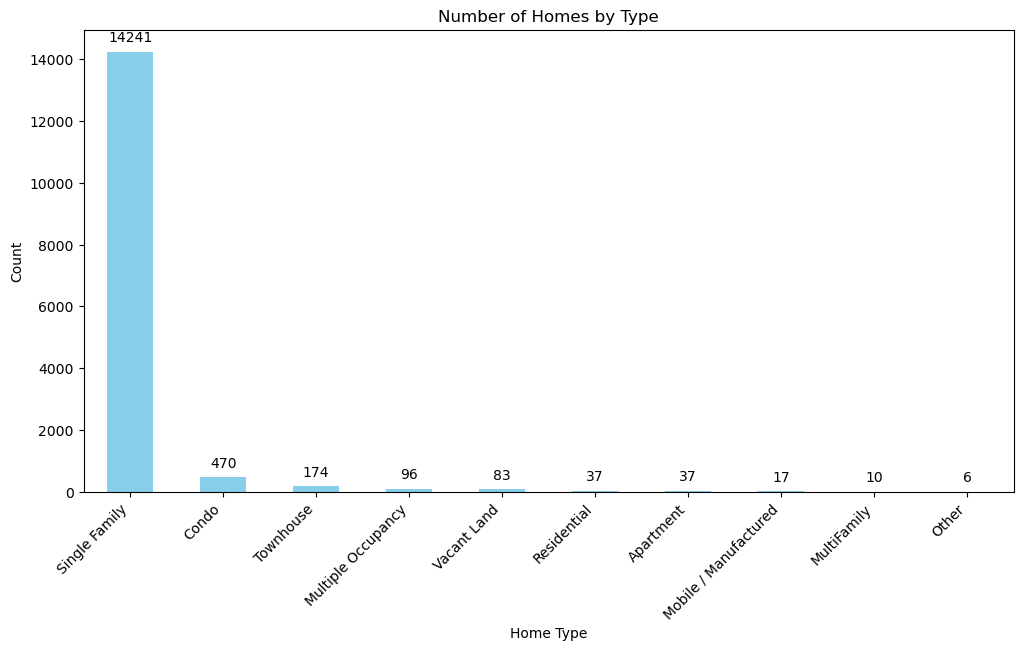

In [21]:
import matplotlib.pyplot as plt

# Bar chart indicating the numer of homeTypes wich is the most common in the dataset 
home_type_counts = df['homeType'].value_counts()

# Bar chart with clear labels
plt.figure(figsize=(12, 6))
bar_plot = home_type_counts.plot(kind='bar', color='skyblue')

# Add labels to the bars
for p in bar_plot.patches:
    bar_plot.annotate(f'{p.get_height()}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Number of Homes by Type')
plt.xlabel('Home Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()


In [22]:
# Before procceding with standerising the data we need to check if any predictor (column) is categorical
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

# Convert categorical predictor to continuous using LabelEncoder for any data that is datatype of Object
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Categorical Columns: Index(['city', 'streetAddress', 'description', 'homeType', 'latest_saledate',
       'latestPriceSource', 'homeImage'],
      dtype='object')


In [23]:
print("check datatypes again for object data type : ")
df.dtypes

check datatypes again for object data type : 


zpid                            int64
city                            int32
streetAddress                   int32
zipcode                         int64
description                     int32
latitude                      float64
longitude                     float64
propertyTaxRate               float64
garageSpaces                    int64
hasAssociation                   bool
hasCooling                       bool
hasGarage                        bool
hasHeating                       bool
hasSpa                           bool
hasView                          bool
homeType                        int32
parkingSpaces                   int64
yearBuilt                       int64
latestPrice                   float64
numPriceChanges                 int64
latest_saledate                 int32
latest_salemonth                int64
latest_saleyear                 int64
latestPriceSource               int32
numOfPhotos                     int64
numOfAccessibilityFeatures      int64
numOfApplian

In [24]:
# Dropp columns that we dont need such
columns_to_drop = ['zpid', 'streetAddress', 'description', 'homeImage', 'garageSpaces', 'hasAssociation', 'hasCooling','hasGarage'
                   , 'hasHeating', 'hasSpa', 'hasView']
df = df.drop(columns=columns_to_drop)

# Being standerising data
# Get column names first 
names = df.columns
# Create the Scaler objectscaler = StandardScaler()
scaler = StandardScaler()
# Fit your data on the scaler object
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=names)
scaled_df.head()




,city,zipcode,latitude,longitude,propertyTaxRate,homeType,parkingSpaces,yearBuilt,latestPrice,numPriceChanges,...,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories
0,17.155768,-4.019137,1.433803,1.362892,-0.265248,0.183428,0.573298,1.086498,-0.458476,0.790858,...,-0.209308,-0.136519,0.07945,-0.535249,-1.673595,-0.533854,-0.492151,0.300632,0.658444,1.017276
1,17.155768,-4.019137,1.454849,1.379193,-0.265248,0.183428,0.573298,1.132840,-0.480543,-0.817305,...,-0.209308,-0.136519,0.07945,-0.410445,-1.673595,-0.533854,-0.492151,-0.647765,0.658444,-0.892288
2,17.155768,-4.019137,1.218441,1.638033,-0.265248,0.183428,-0.905241,1.364549,-0.566327,-0.817305,...,8.303877,-0.136519,0.07945,-0.597651,-1.494404,-0.396030,-0.492151,-0.647765,-0.518146,-0.892288
3,17.155768,-4.019137,1.449066,1.379644,-0.265248,0.183428,0.573298,1.132840,-0.601910,0.388817,...,-0.209308,-0.136519,0.07945,-0.410445,-1.673595,-0.533854,-0.492151,-0.647765,-0.518146,-0.892288
4,17.155768,-4.019137,1.503275,1.436293,-0.265248,0.183428,-0.905241,0.623079,-0.602131,-0.013224,...,-0.209308,-0.136519,0.07945,-0.660053,-0.956832,-0.043812,-0.492151,0.300632,-0.518146,1.017276


In [25]:
# Data Statistics and Plots
print("Data Statistics:")
print(scaled_df.describe())

Data Statistics:
               city       zipcode      latitude     longitude  \
count  15171.000000  1.517100e+04  1.517100e+04  1.517100e+04   
mean       0.000000  1.028135e-13  1.798487e-14  3.171331e-14   
std        1.000033  1.000033e+00  1.000033e+00  1.000033e+00   
min       -0.076862 -6.295130e+00 -2.130212e+00 -2.874734e+00   
25%       -0.076862 -4.728224e-01 -9.104181e-01 -7.021088e-01   
50%       -0.076862  1.623384e-01 -7.404157e-02  1.061583e-01   
75%       -0.076862  6.916391e-01  7.733204e-01  7.157021e-01   
max       22.899978  1.220940e+00  2.327801e+00  2.467510e+00   

       propertyTaxRate      homeType  parkingSpaces     yearBuilt  \
count     1.517100e+04  1.517100e+04   1.517100e+04  1.517100e+04   
mean     -4.773483e-15 -3.746847e-16   8.243064e-17  2.038285e-15   
std       1.000033e+00  1.000033e+00   1.000033e+00  1.000033e+00   
min      -2.652484e-01 -5.902018e+00  -9.052406e-01 -3.872085e+00   
25%      -2.652484e-01  1.834281e-01  -9.052406e-01 

Plotting distributions:   0%|          | 0/32 [00:00<?, ?it/s]

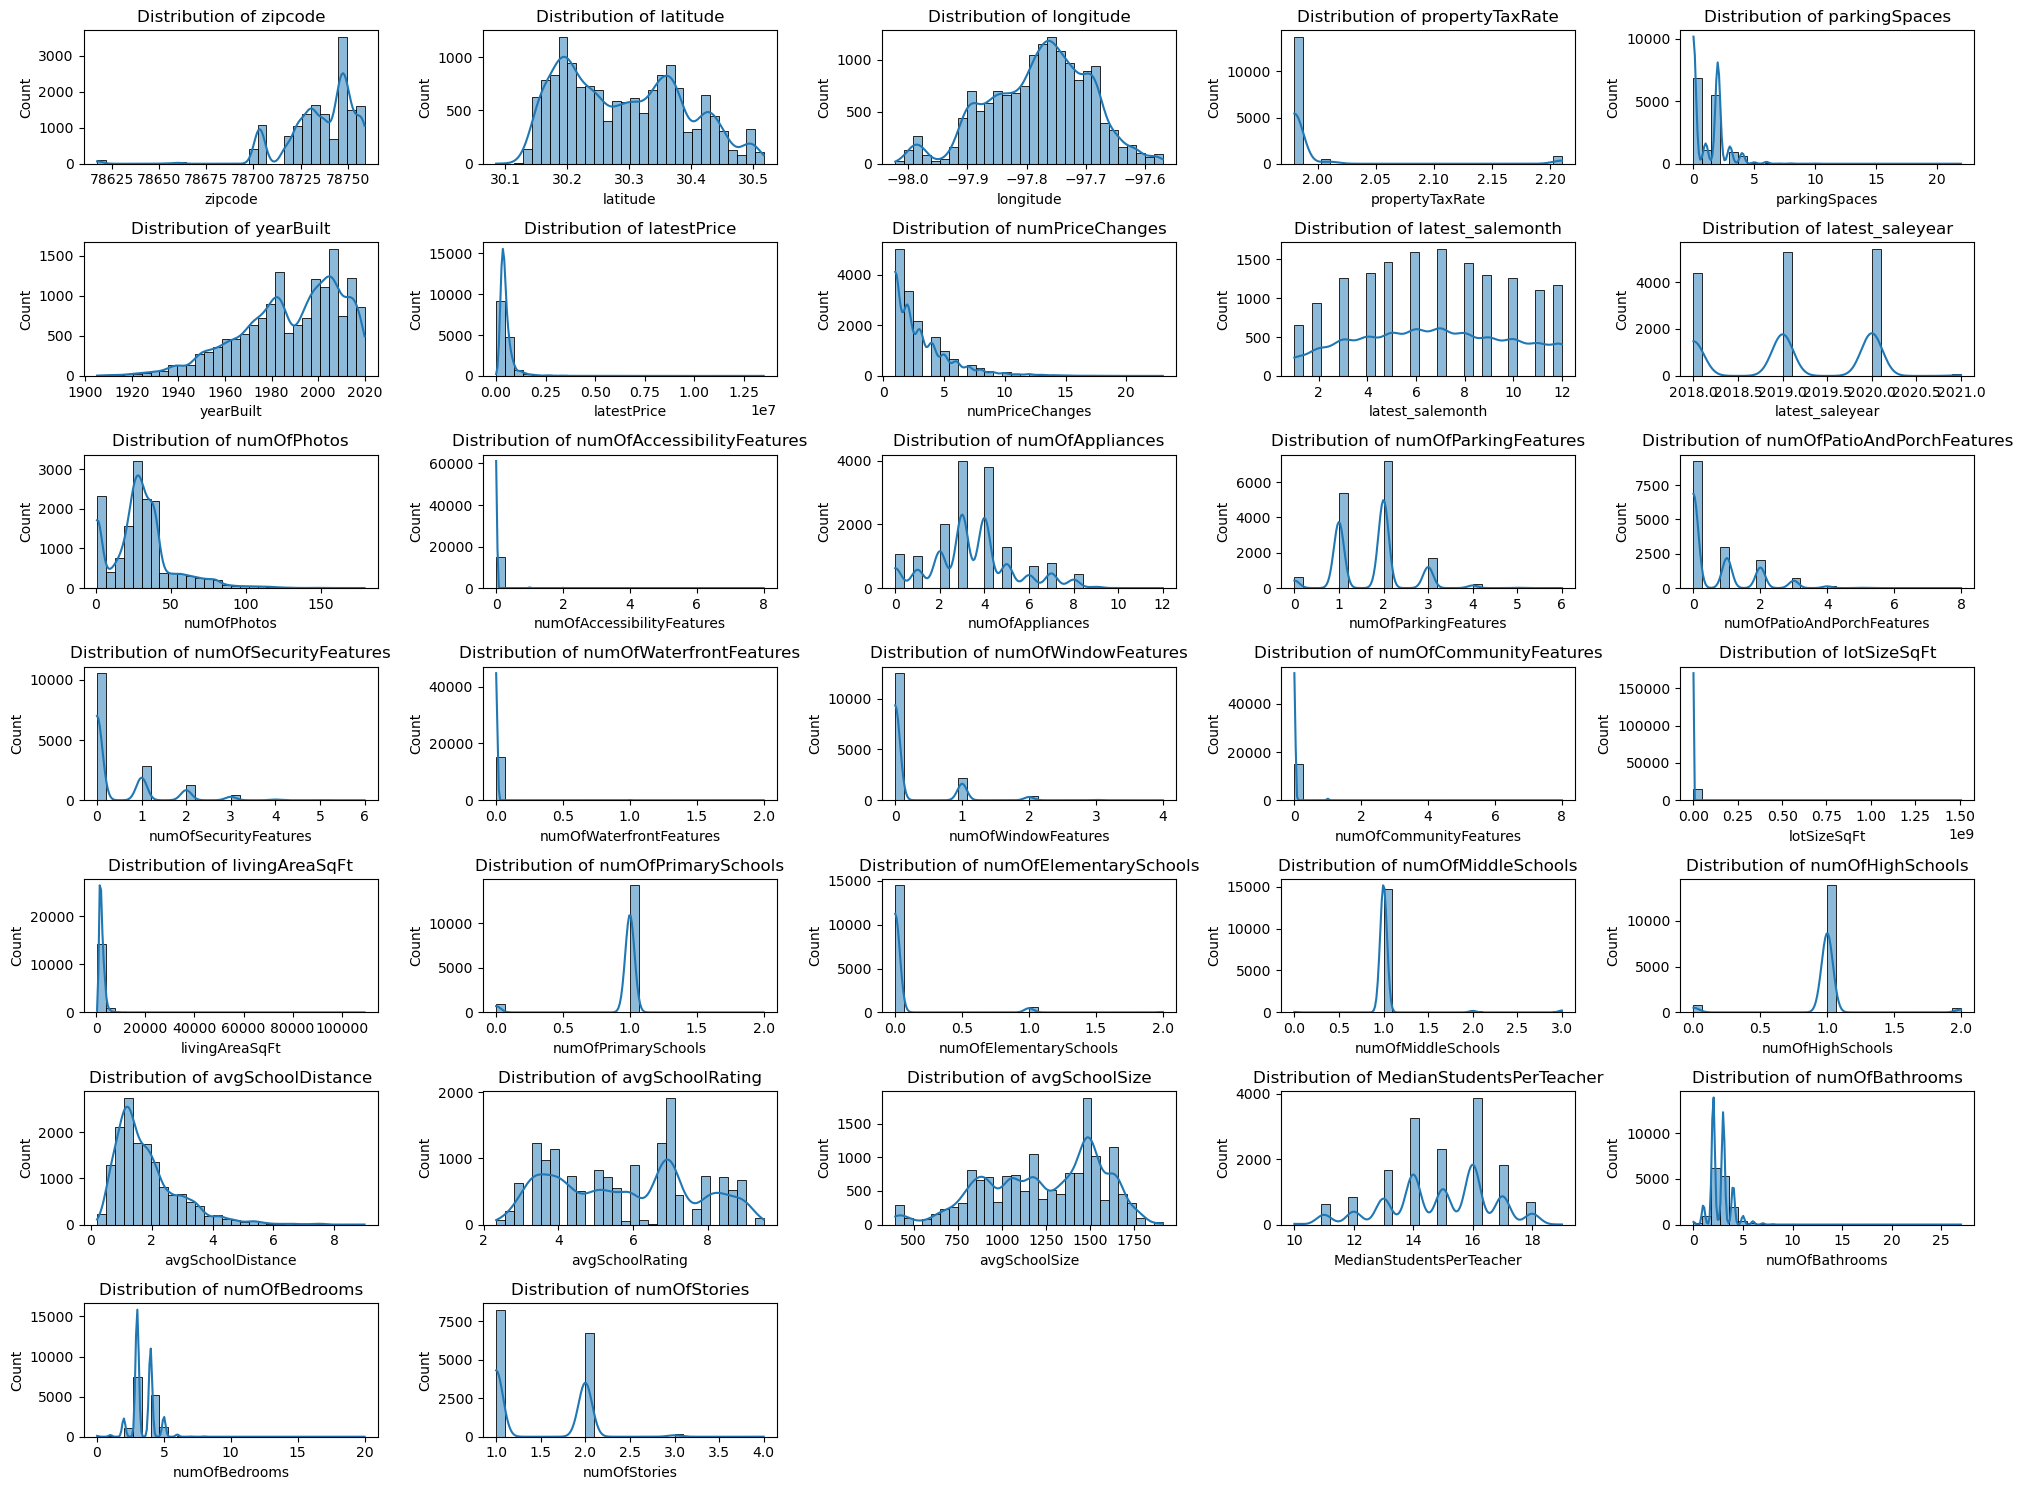

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm 
import math
# Select numeric columns for distribution
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Calculate the number of rows and columns for subplots
num_cols = len(numeric_cols)
num_rows = math.ceil(num_cols / 5)  # Adjust the divisor based on your preference
num_cols_per_row = min(num_cols, 5)  # Maximum 5 columns per row, adjust as needed

# Plot distorbustion
plt.figure(figsize=(20, 15))
for i, col in enumerate(tqdm(numeric_cols, desc='Plotting distributions')):
    plt.subplot(num_rows, num_cols_per_row, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title('Distribution of ' + col)
plt.tight_layout()
plt.show()

C:\Users\youssif\AppData\Local\Temp\ipykernel_37092\4023504442.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


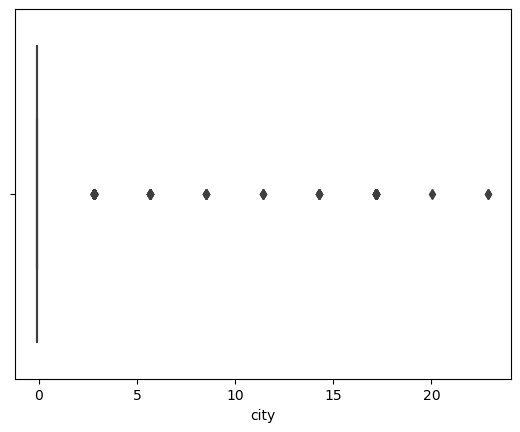

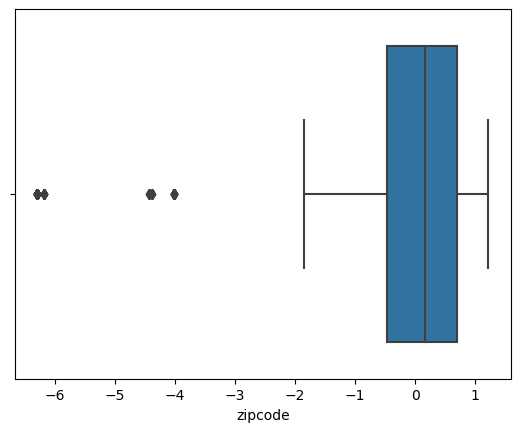

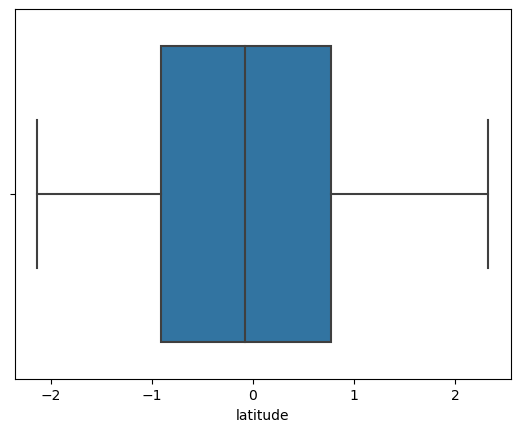

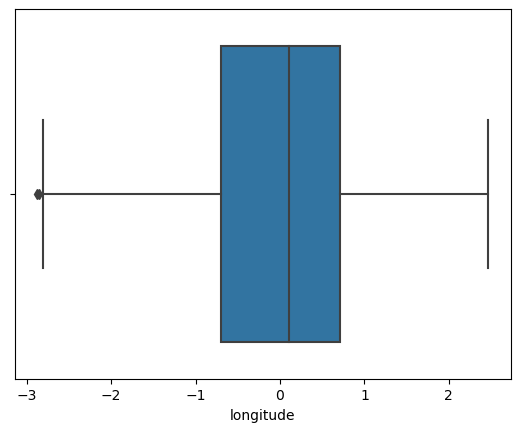

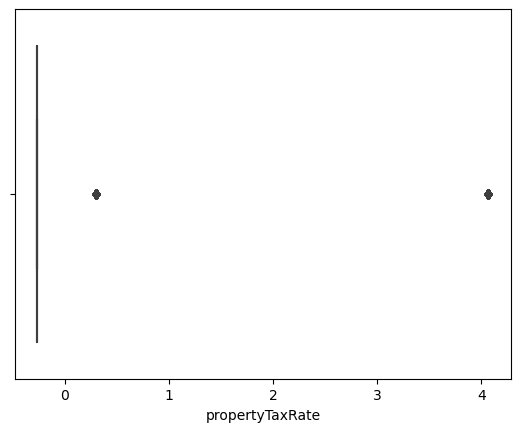

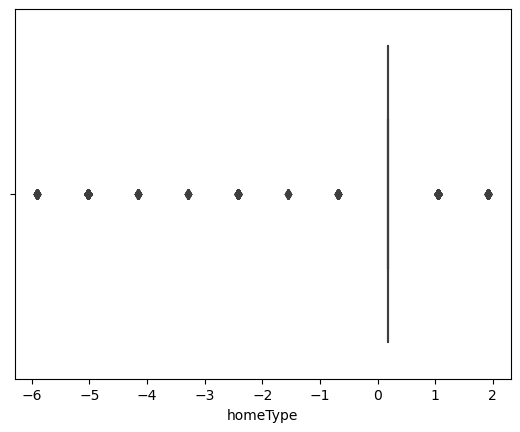

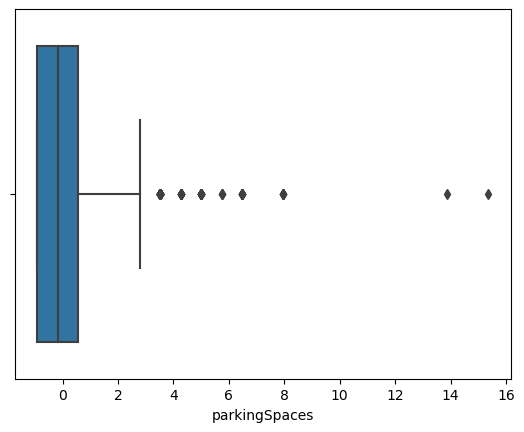

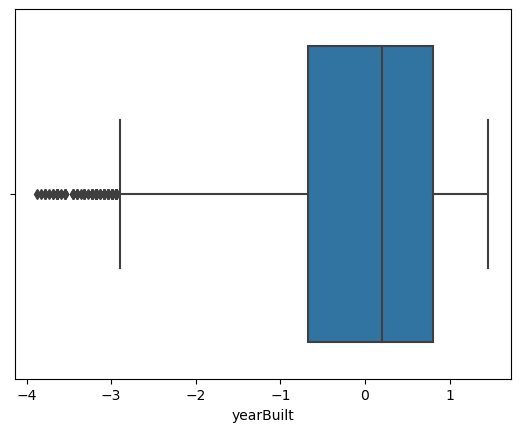

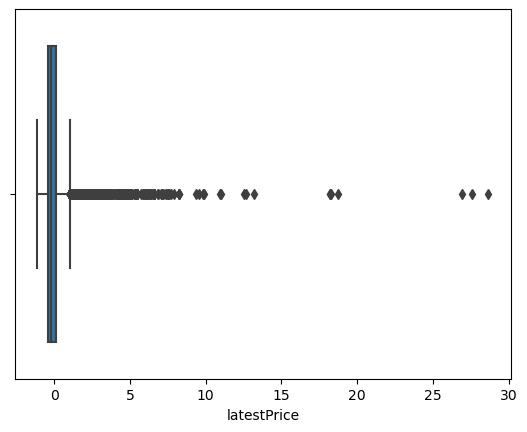

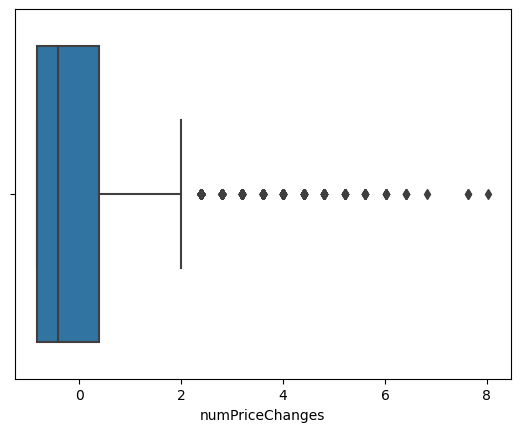

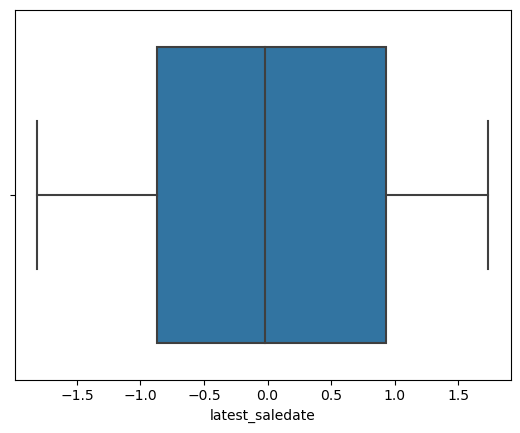

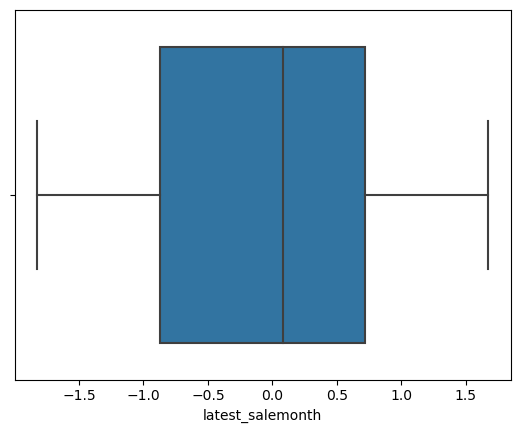

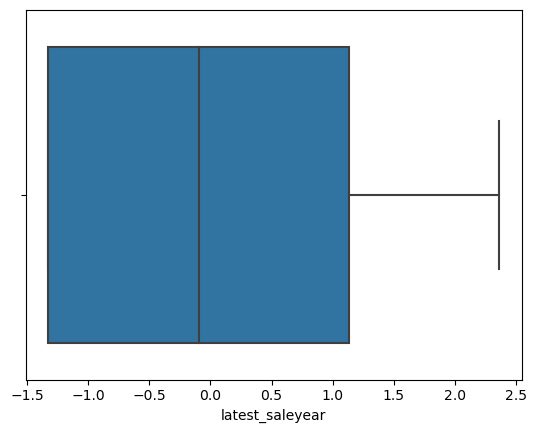

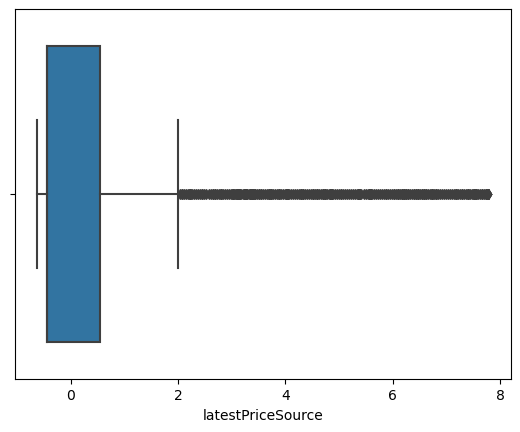

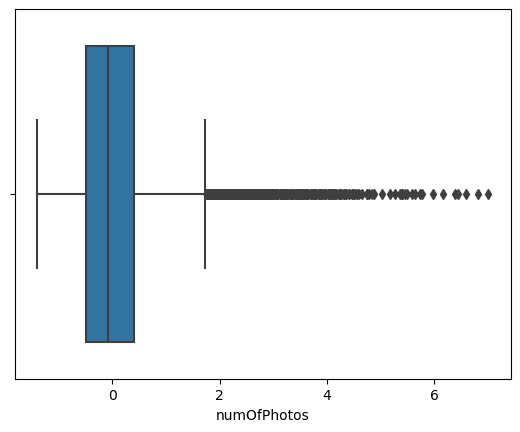

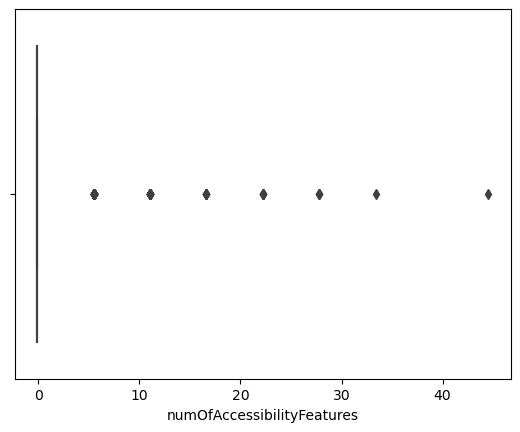

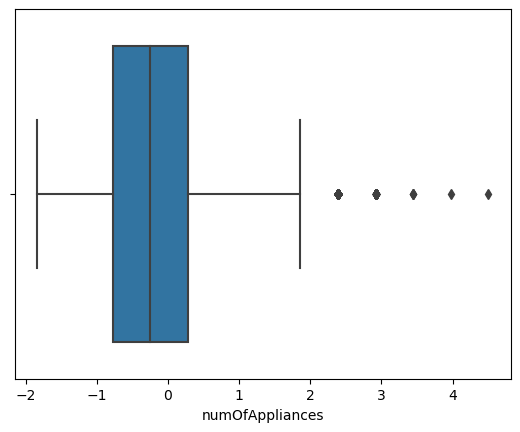

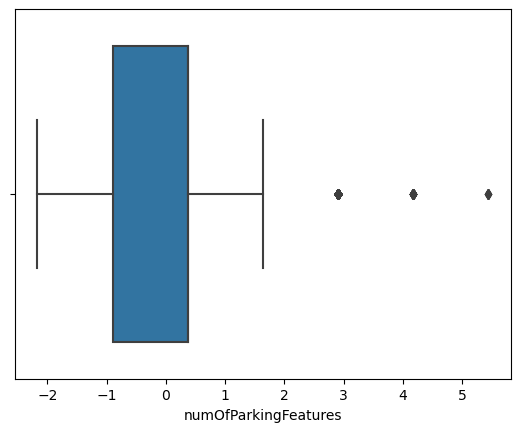

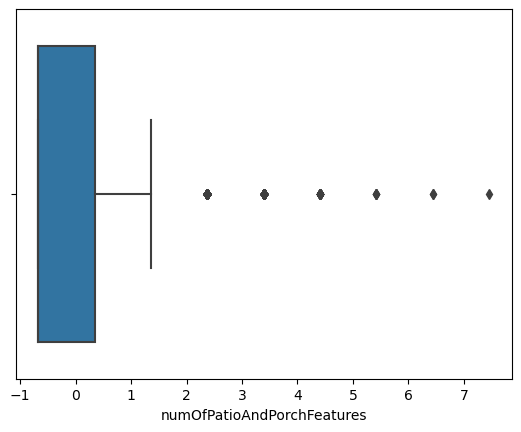

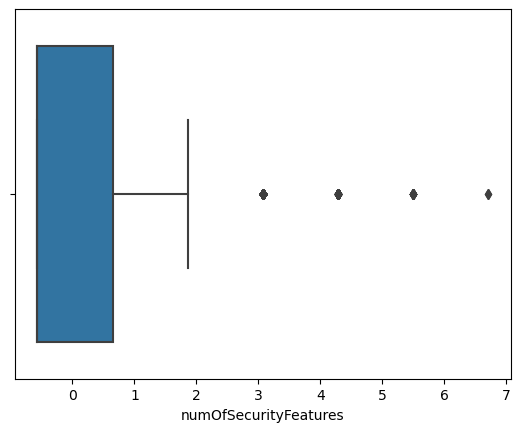

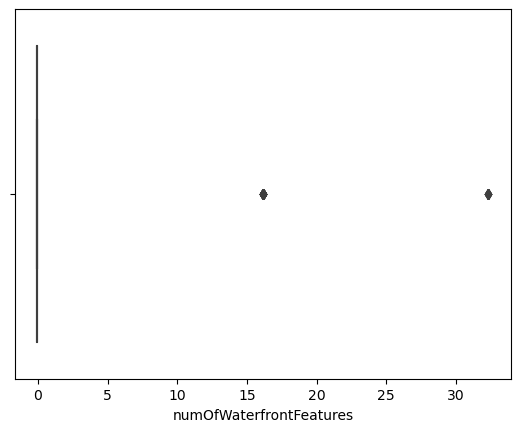

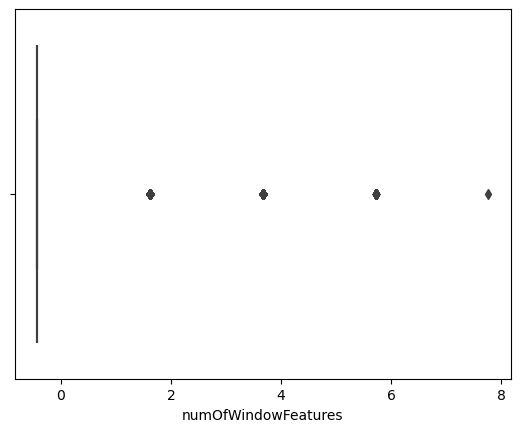

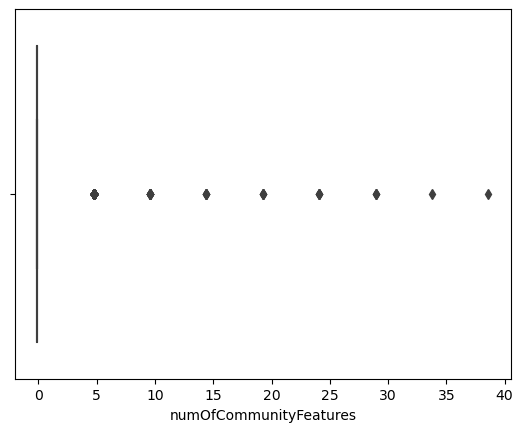

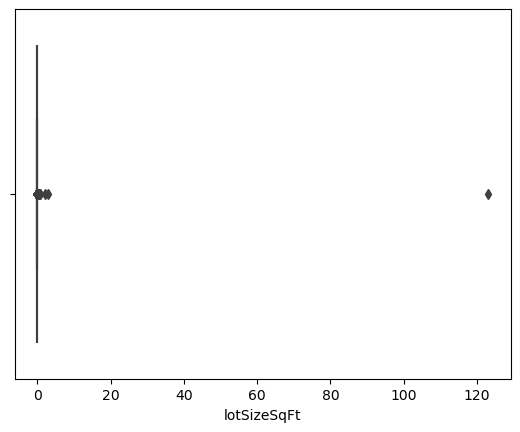

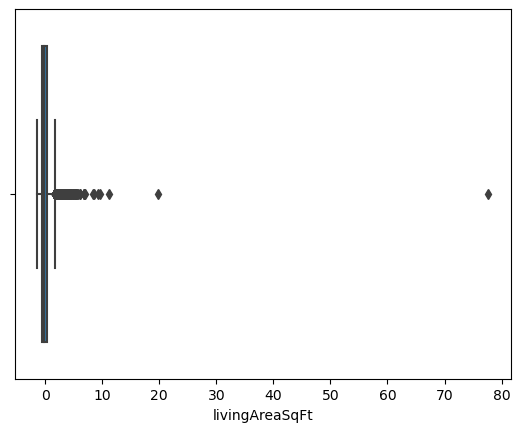

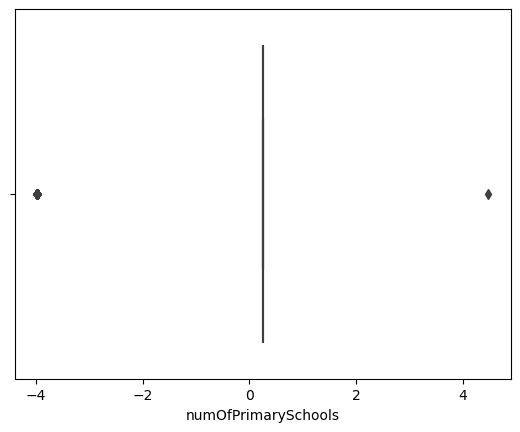

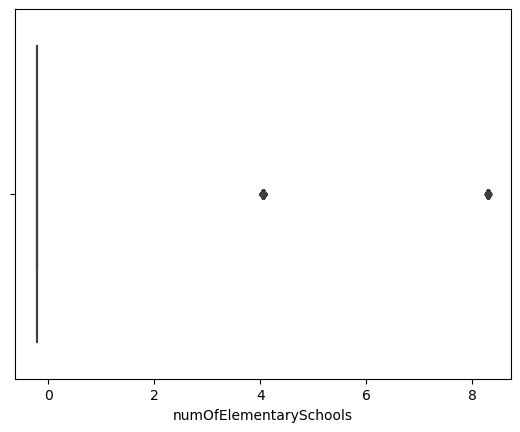

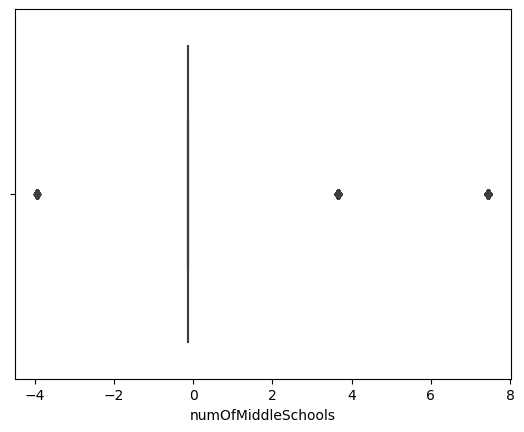

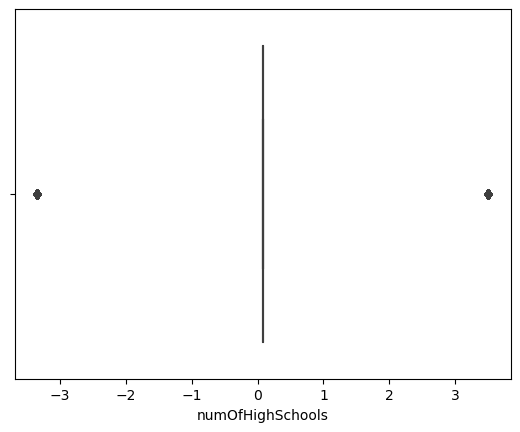

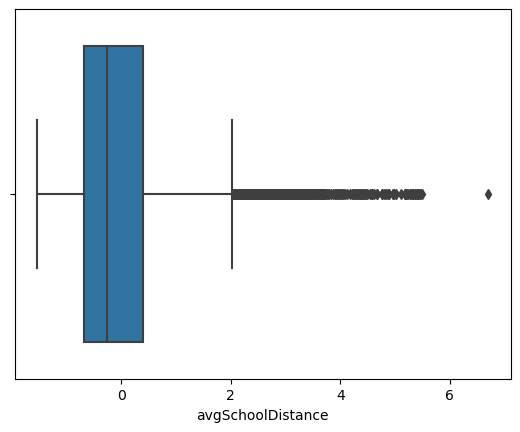

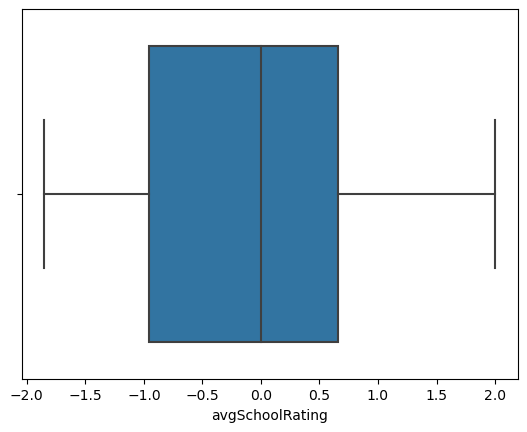

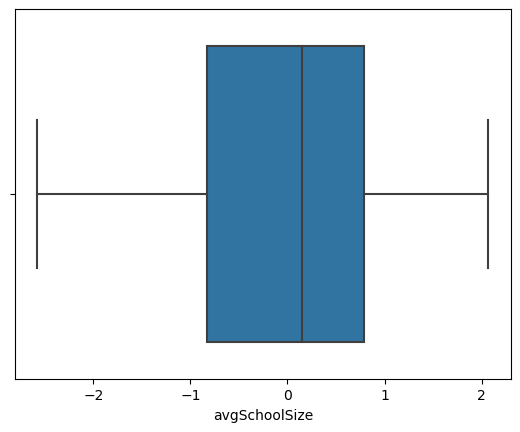

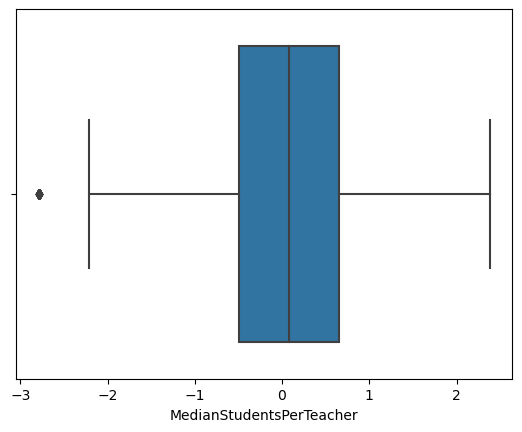

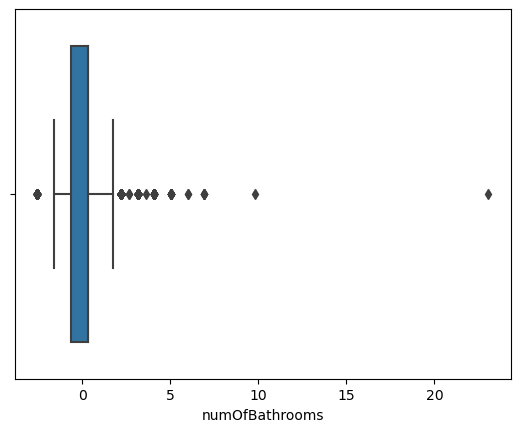

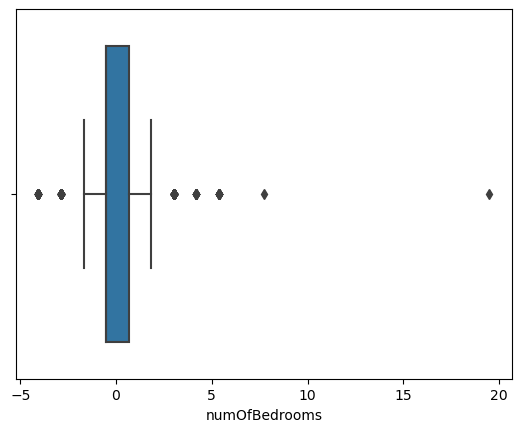

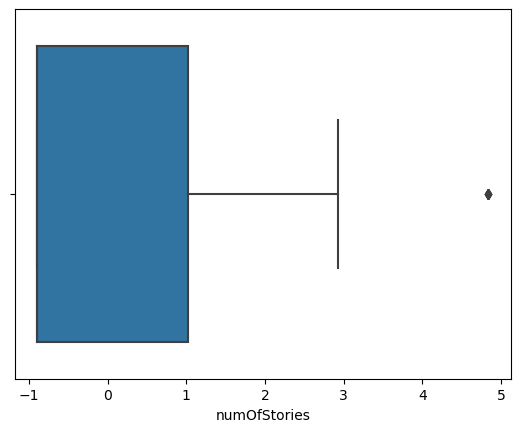

In [27]:
# Visualsing data: 
for column in scaled_df:
    plt.figure()
    sns.boxplot(x=scaled_df[column])

<Axes: >

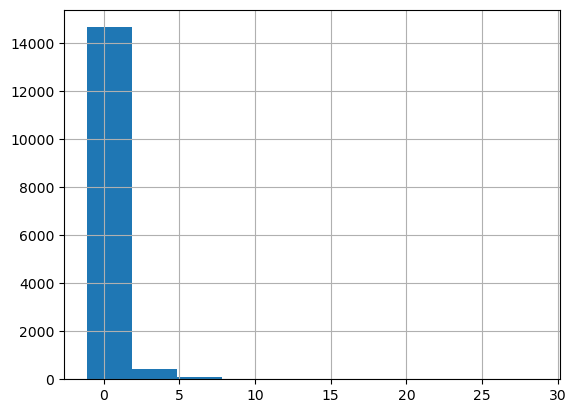

In [28]:
# Visualsing target variable 
scaled_df['latestPrice'].hist()

<Axes: >

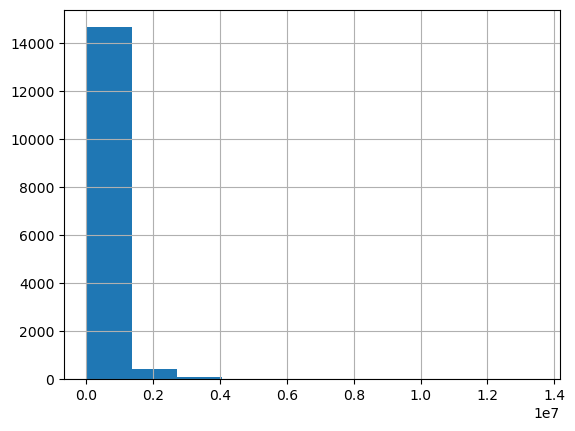

In [29]:
df['latestPrice'].hist()

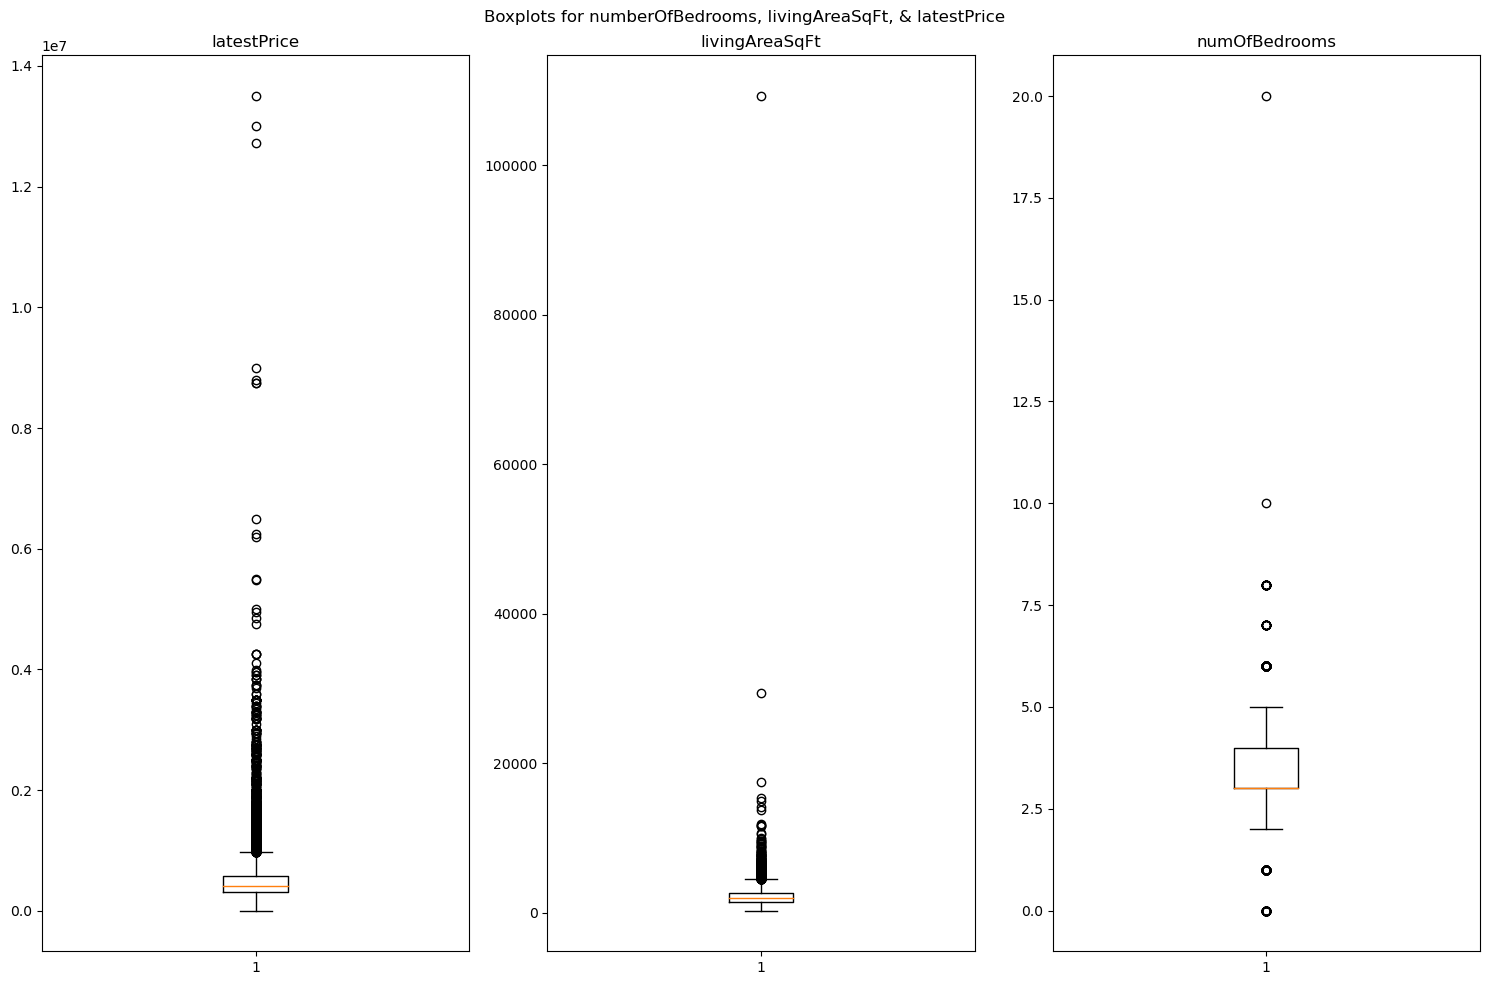

In [30]:
# Data visualising
# Reference : https://www.kaggle.com/code/nathanfstern/austin-house-price-prediction
figure, axis = plt.subplots(1, 3, figsize=(15, 10))

# Boxplot for latestPrice
axis[0].boxplot(df['latestPrice'])
axis[0].set_title("latestPrice")

# Boxplot for livingAreaSqFt
axis[1].boxplot(df['livingAreaSqFt'])
axis[1].set_title("livingAreaSqFt")

# Boxplot for numOfBedrooms
axis[2].boxplot(df['numOfBedrooms'])
axis[2].set_title("numOfBedrooms")

# Customize the figure
figure.suptitle("Boxplots for numberOfBedrooms, livingAreaSqFt, & latestPrice")
plt.tight_layout()
plt.show()


In [31]:
# Cleaning data by removing outliers

# Remove number of bedrooms that are less than one and that are greater than six
df = df[(df["numOfBedrooms"] >= 1) & (df["numOfBedrooms"] <= 6)]

# Remove the number of bathrooms that are less than one, houses would usally have atleast one bathroom in a house

df = df[df["numOfBathrooms"] >= 1]

# Remove data that exceedes the threshold of 20,000 square feet

df = df[df["livingAreaSqFt"] <= 20000]

# Remove rows where the house value is less than 1,000,000 (reason: unrelisitc house value)

df = df[df["latestPrice"] <= 1000000]

df.head()


,city,zipcode,latitude,longitude,propertyTaxRate,homeType,parkingSpaces,yearBuilt,latestPrice,numPriceChanges,...,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories
0,6,78660,30.430632,-97.663078,1.98,7,2,2012,305000.0,5,...,0,1,1,1.266667,2.666667,1063,14,3.0,4,2
1,6,78660,30.432673,-97.661697,1.98,7,2,2013,295000.0,1,...,0,1,1,1.400000,2.666667,1063,14,2.0,4,1
2,6,78660,30.409748,-97.639771,1.98,7,0,2018,256125.0,1,...,2,1,1,1.200000,3.000000,1108,14,2.0,3,1
3,6,78660,30.432112,-97.661659,1.98,7,2,2013,240000.0,4,...,0,1,1,1.400000,2.666667,1063,14,2.0,3,1
4,6,78660,30.437368,-97.656860,1.98,7,0,2002,239900.0,3,...,0,1,1,1.133333,4.000000,1223,14,3.0,3,2


In [32]:
# independat variable X
X = scaled_df.drop('latestPrice', axis = 1)

# Our descriptive feature
# print (X.describe())
print (X.info())
print (X.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        15171 non-null  float64
 1   zipcode                     15171 non-null  float64
 2   latitude                    15171 non-null  float64
 3   longitude                   15171 non-null  float64
 4   propertyTaxRate             15171 non-null  float64
 5   homeType                    15171 non-null  float64
 6   parkingSpaces               15171 non-null  float64
 7   yearBuilt                   15171 non-null  float64
 8   numPriceChanges             15171 non-null  float64
 9   latest_saledate             15171 non-null  float64
 10  latest_salemonth            15171 non-null  float64
 11  latest_saleyear             15171 non-null  float64
 12  latestPriceSource           15171 non-null  float64
 13  numOfPhotos                 151

In [33]:
# Target variable y

y = scaled_df['latestPrice']

print (y.describe())
print (y.shape)


count    1.517100e+04
mean    -5.245586e-17
std      1.000033e+00
min     -1.119375e+00
25%     -4.496493e-01
50%     -2.378084e-01
75%      1.373264e-01
max      2.865861e+01
Name: latestPrice, dtype: float64
(15171,)


In [34]:
# Build the linear regression model

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.20, random_state=1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(12136, 35)
(12136,)
(3035, 35)
(3035,)


In [35]:
# model building 

regression = linear_model.LinearRegression() # we create an object of the LR class
regression.fit(X_train, Y_train) # training / fitting model on data;


print ("\n\nLet's evalaute our model on our held-out test data\n")

print("R-Sqaured: %.3f"
      % regression.score(X_test,Y_test)) # R-squared 

Y_pred = regression.predict(X_test) 
print("Mean squared error: %.3f"
      % mean_squared_error(Y_test, Y_pred))  # Test MSE

print("Mean absolute error: %.3f"
      % mean_absolute_error(Y_test, Y_pred))

print ("\n\n\nLet's see how parameters were learnt in training.\n")

print("The intercept / beta_0 is {}".format(regression.intercept_)) 
for i, col_name in enumerate(X_train.columns):
    print("The coefficient (beta_{}) for {} is {}".format(i, col_name, regression.coef_[i]))



Let's evalaute our model on our held-out test data

R-Sqaured: 0.504
Mean squared error: 0.532
Mean absolute error: 0.371



Let's see how parameters were learnt in training.

The intercept / beta_0 is -0.0025255501959973847
The coefficient (beta_0) for city is -0.05732273731466635
The coefficient (beta_1) for zipcode is -0.14404999527457346
The coefficient (beta_2) for latitude is 0.0053322651010905
The coefficient (beta_3) for longitude is 0.07164866706105415
The coefficient (beta_4) for propertyTaxRate is -0.1482679411214912
The coefficient (beta_5) for homeType is 0.02027867234223794
The coefficient (beta_6) for parkingSpaces is -0.0002848407197953001
The coefficient (beta_7) for yearBuilt is -0.11361741417184698
The coefficient (beta_8) for numPriceChanges is -0.04761525515231304
The coefficient (beta_9) for latest_saledate is 0.36044166741676015
The coefficient (beta_10) for latest_salemonth is -0.10577163047315867
The coefficient (beta_11) for latest_saleyear is -0.30547228288

In [36]:
# Select four informative features
selected_features = ['zipcode', 'livingAreaSqFt', 'numOfBedrooms', 'latestPrice', 'avgSchoolDistance']

# Subset the DataFrame with these features
subset_df = df[selected_features]

# Display the subset
print(subset_df.head())


   zipcode  livingAreaSqFt  numOfBedrooms  latestPrice  avgSchoolDistance
0    78660          2601.0              4     305000.0           1.266667
1    78660          1768.0              4     295000.0           1.400000
2    78660          1478.0              3     256125.0           1.200000
3    78660          1678.0              3     240000.0           1.400000
4    78660          2132.0              3     239900.0           1.133333


In [37]:
# checking for null values : 
print(subset_df.isnull().sum())
print("\nthere are no null values, the data is clean")

zipcode              0
livingAreaSqFt       0
numOfBedrooms        0
latestPrice          0
avgSchoolDistance    0
dtype: int64

there are no null values, the data is clean


In [38]:
#Being standarizing data

scaler = StandardScaler()
scaled_df = scaler.fit_transform(subset_df)
scaled_df = pd.DataFrame(scaled_df, columns=selected_features)

scaled_df.head()

,zipcode,livingAreaSqFt,numOfBedrooms,latestPrice,avgSchoolDistance
0,-4.10687,0.640604,0.799319,-0.697216,-0.538263
1,-4.10687,-0.365712,0.799319,-0.752471,-0.408165
2,-4.10687,-0.716050,-0.513209,-0.967272,-0.603313
3,-4.10687,-0.474438,-0.513209,-1.056370,-0.408165
4,-4.10687,0.074022,-0.513209,-1.056922,-0.668362


In [39]:
#Statistics and plots: 

print("Data Statistics:")
print(scaled_df.describe())

Data Statistics:
            zipcode  livingAreaSqFt  numOfBedrooms   latestPrice  \
count  1.407900e+04    1.407900e+04   1.407900e+04  1.407900e+04   
mean   3.205502e-13   -2.583975e-16  -2.260978e-16 -1.211238e-17   
std    1.000036e+00    1.000036e+00   1.000036e+00  1.000036e+00   
min   -6.408467e+00   -2.139147e+00  -3.138263e+00 -2.352084e+00   
25%   -5.206601e-01   -7.486677e-01  -5.132086e-01 -7.248987e-01   
50%    2.286972e-01   -2.026237e-01  -5.132086e-01 -1.999271e-01   
75%    6.569013e-01    5.644956e-01   7.993189e-01  5.183794e-01   
max    1.192157e+00    7.944546e+00   3.424374e+00  3.142961e+00   

       avgSchoolDistance  
count       1.407900e+04  
mean        3.229969e-16  
std         1.000036e+00  
min        -1.579052e+00  
25%        -7.008865e-01  
50%        -2.455413e-01  
75%         4.374765e-01  
max         7.007458e+00  


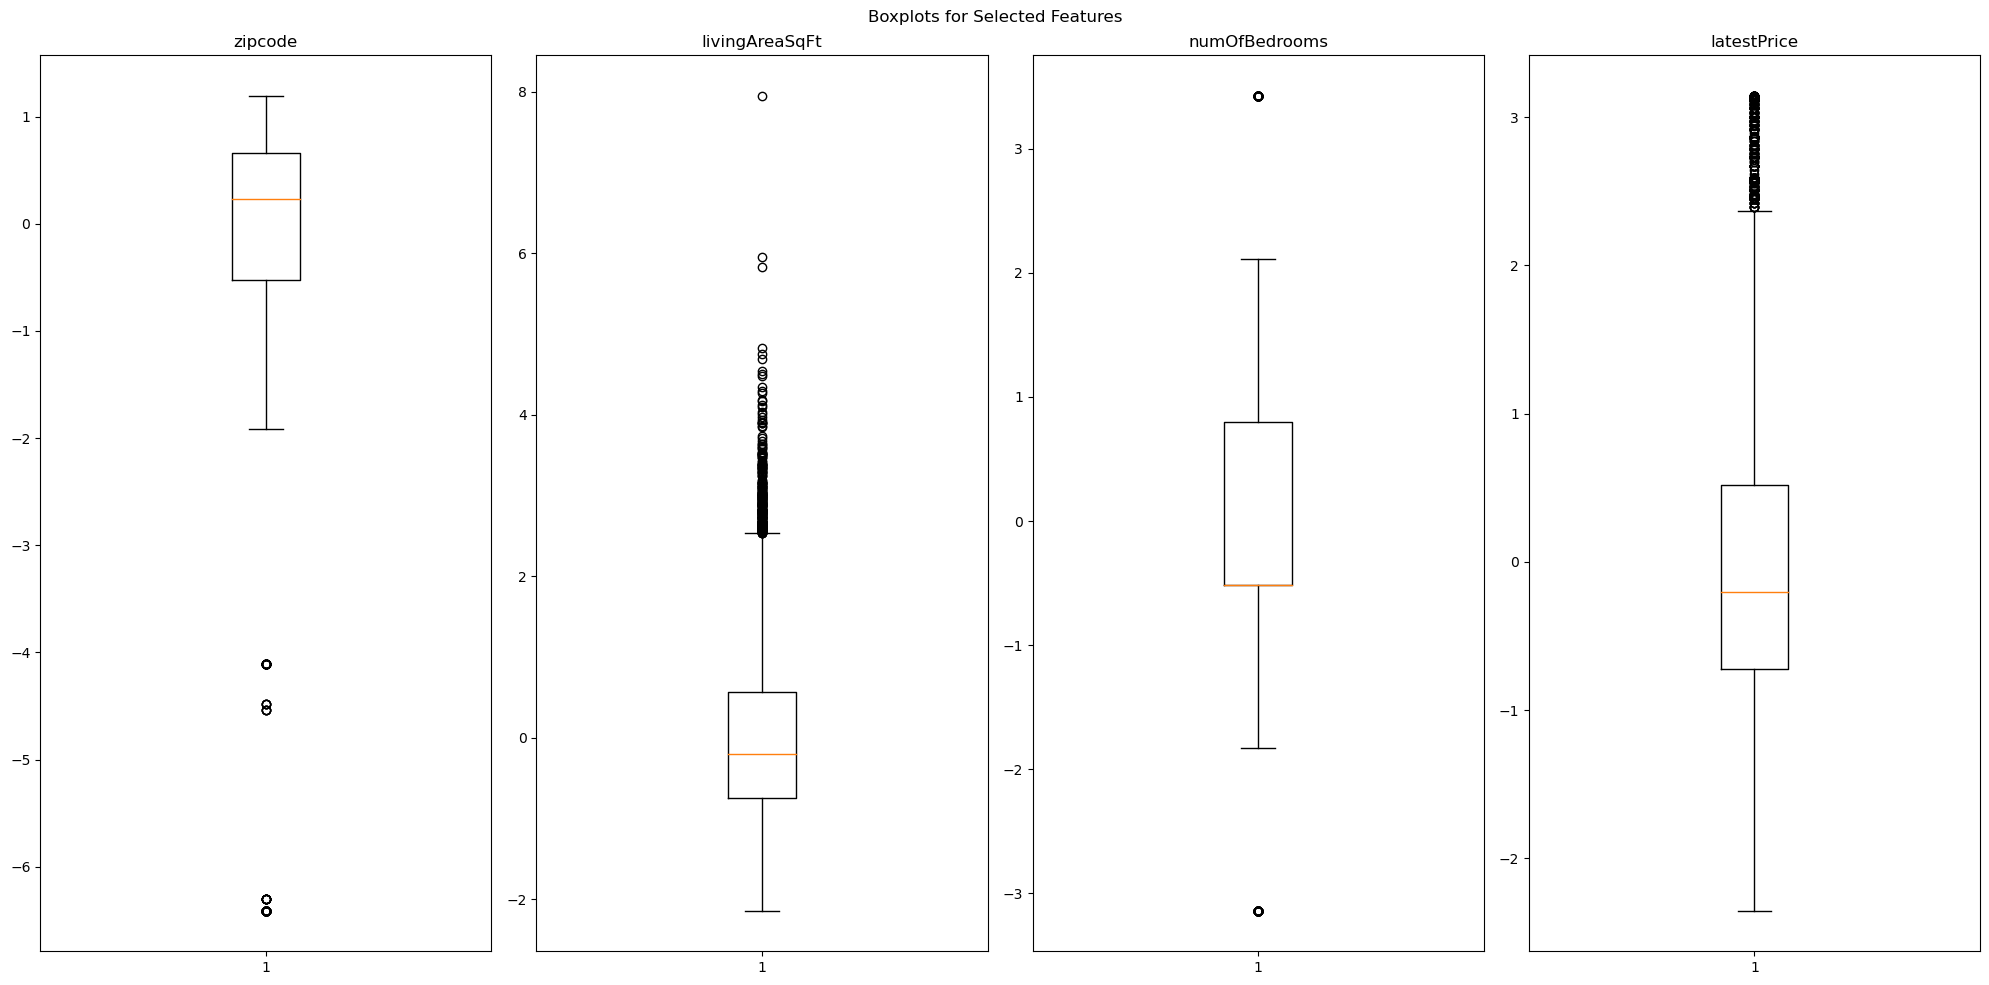

In [40]:
#data visualizing for selected features

figure, axis = plt.subplots(1, 4, figsize=(20, 10))

#Boxplot for zipcode
axis[0].boxplot(scaled_df['zipcode'])
axis[0].set_title("zipcode")

#Boxplot for livingAreaSqFt
axis[1].boxplot(scaled_df['livingAreaSqFt'])
axis[1].set_title("livingAreaSqFt")

#Boxplot for numOfBedrooms
axis[2].boxplot(scaled_df['numOfBedrooms'])
axis[2].set_title("numOfBedrooms")

#Boxplot for latestPrice
axis[3].boxplot(scaled_df['latestPrice'])
axis[3].set_title("latestPrice")

#Customize the figure
figure.suptitle("Boxplots for Selected Features")
plt.tight_layout()
plt.show()


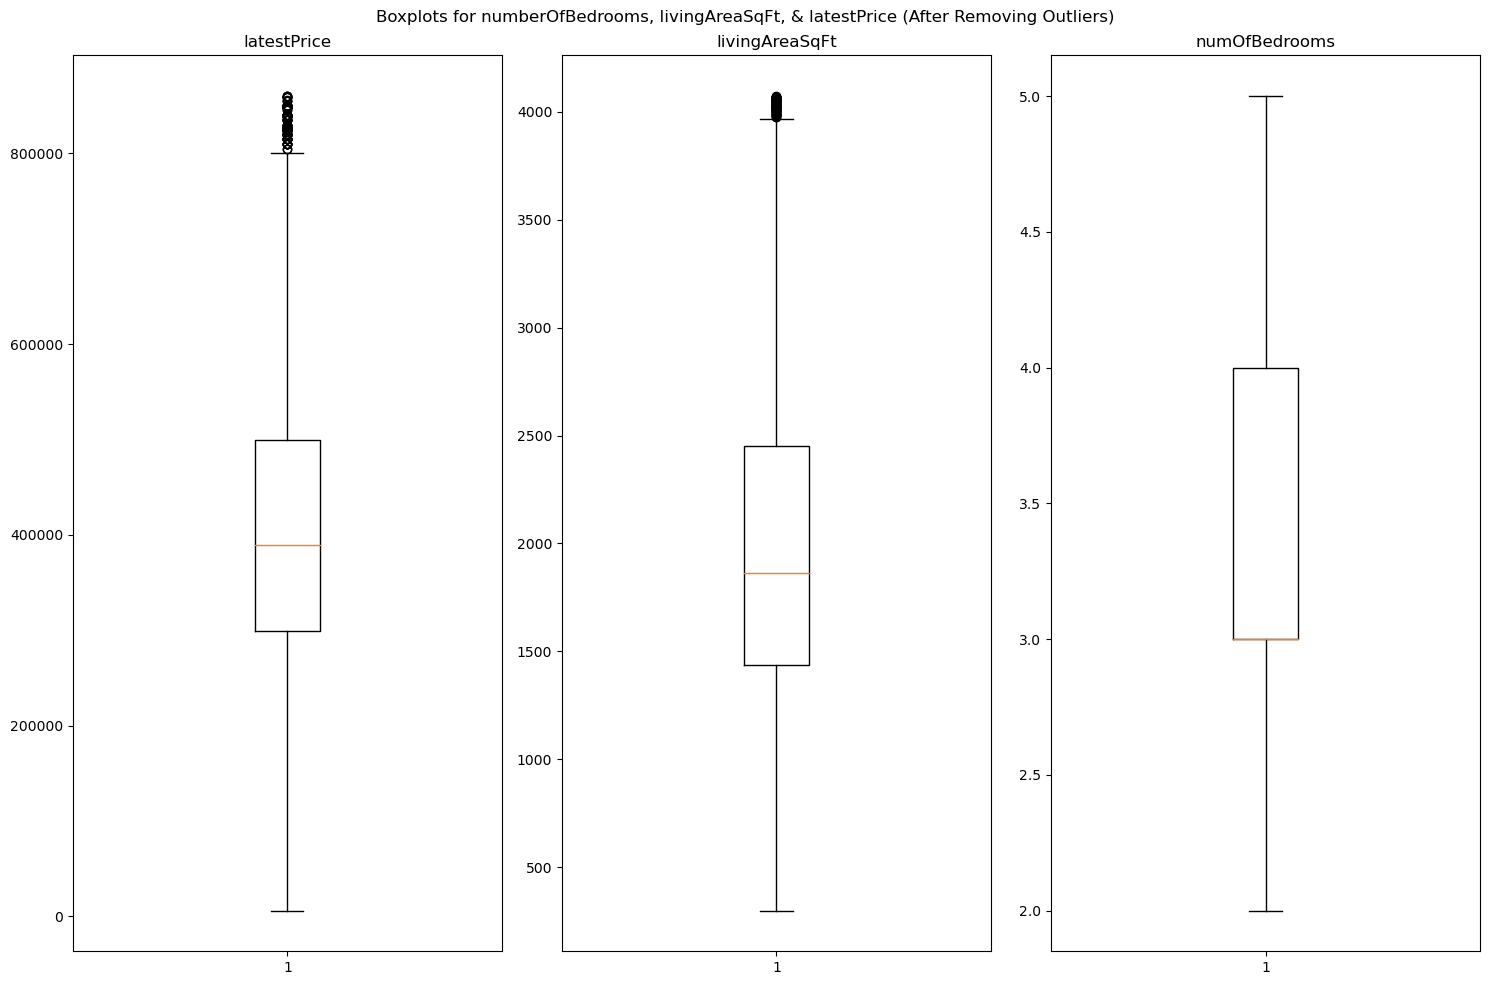

Home Types & count after data cleaning: 
7    13300
1      457
8      170
4       70
6       35
0       17
2       16
3        8
9        3
5        3
Name: homeType, dtype: int64

Home type percentiles : 


7    0.944669
1    0.032460
8    0.012075
4    0.004972
6    0.002486
0    0.001207
2    0.001136
3    0.000568
9    0.000213
5    0.000213
Name: homeType, dtype: float64

In [41]:
# outliers removal based on wisker plot, any value above the min and max wisker we should remove 
# The whiskers that emerge from the top and bottom of the main rectangle in a box plot
# are designed to show the range of the data.
# The top whisker extends to whichever is lower of the maximum value of the feature or the
# upper quartile plus 1.5 times the IQR.
# The bottom whisker extends to whichever is higher of the minimum value of the feature
# or the lower quartile minus 1.5 times the IQR.
# Values that fall outside of whiskers are called outliers  


# code refference : https://www.geeksforgeeks.org/detect-and-remove-the-outliers-using-python/
# second refference for code: https://stackoverflow.com/questions/50461349/how-to-remove-outlier-from-dataframe-using-iqr
# Function to remove outliers based on IQR range
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25) #first quaritle 25%
    Q3 = data[column].quantile(0.75)  # second quartile 75%
    IQR = Q3 - Q1                     # Inter quartile range (IQR)
    lower_bound = Q1 - 1.5 * IQR     #outliers lowerbound 
    upper_bound = Q3 + 1.5 * IQR     #outliers uperbound
    data_no_outliers = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return data_no_outliers

# Remove the outliers (do not incluide ZIP code)
selected_features = ['latestPrice', 'livingAreaSqFt', 'numOfBedrooms']
df_no_outliers = df.copy()
for feature in selected_features:
    df_no_outliers = remove_outliers(df_no_outliers, feature)

# Data visualizing with boxplots after removing outliers

figure, axis = plt.subplots(1, 3, figsize=(15, 10))

# Boxplot for latestPrice
axis[0].boxplot(df_no_outliers['latestPrice'])
axis[0].set_title("latestPrice")

# Boxplot for livingAreaSqFt
axis[1].boxplot(df_no_outliers['livingAreaSqFt'])
axis[1].set_title("livingAreaSqFt")

# Boxplot for numOfBedrooms
axis[2].boxplot(df_no_outliers['numOfBedrooms'])
axis[2].set_title("numOfBedrooms")

# Customize the figure
figure.suptitle("Boxplots for numberOfBedrooms, livingAreaSqFt, & latestPrice (After Removing Outliers)")
plt.tight_layout()
plt.show()


# Print the counts of each unique value in the 'homeType' column
home_type_counts = df['homeType'].value_counts()
print("Home Types & count after data cleaning: ")
print(home_type_counts)

# provide percentiles 
print("\nHome type percentiles : ")
df['homeType'].value_counts(normalize=True)


In [42]:
print("Data Statistics:")
print(scaled_df.describe())

Data Statistics:
            zipcode  livingAreaSqFt  numOfBedrooms   latestPrice  \
count  1.407900e+04    1.407900e+04   1.407900e+04  1.407900e+04   
mean   3.205502e-13   -2.583975e-16  -2.260978e-16 -1.211238e-17   
std    1.000036e+00    1.000036e+00   1.000036e+00  1.000036e+00   
min   -6.408467e+00   -2.139147e+00  -3.138263e+00 -2.352084e+00   
25%   -5.206601e-01   -7.486677e-01  -5.132086e-01 -7.248987e-01   
50%    2.286972e-01   -2.026237e-01  -5.132086e-01 -1.999271e-01   
75%    6.569013e-01    5.644956e-01   7.993189e-01  5.183794e-01   
max    1.192157e+00    7.944546e+00   3.424374e+00  3.142961e+00   

       avgSchoolDistance  
count       1.407900e+04  
mean        3.229969e-16  
std         1.000036e+00  
min        -1.579052e+00  
25%        -7.008865e-01  
50%        -2.455413e-01  
75%         4.374765e-01  
max         7.007458e+00  


<Axes: >

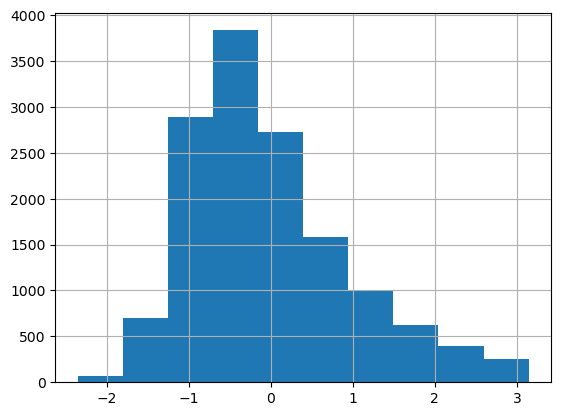

In [43]:
# visualsing target variable
scaled_df['latestPrice'].hist()

In [44]:
#split the data into split and test
X = scaled_df.drop('latestPrice', axis = 1)
print (X.info())
print (X.shape)

y = scaled_df['latestPrice']
print(y.info())
print(y.shape)

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.20, random_state=1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14079 entries, 0 to 14078
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   zipcode            14079 non-null  float64
 1   livingAreaSqFt     14079 non-null  float64
 2   numOfBedrooms      14079 non-null  float64
 3   avgSchoolDistance  14079 non-null  float64
dtypes: float64(4)
memory usage: 440.1 KB
None
(14079, 4)
<class 'pandas.core.series.Series'>
RangeIndex: 14079 entries, 0 to 14078
Series name: latestPrice
Non-Null Count  Dtype  
--------------  -----  
14079 non-null  float64
dtypes: float64(1)
memory usage: 110.1 KB
None
(14079,)
(11263, 4)
(11263,)
(2816, 4)
(2816,)


In [45]:
#model building 

regression = linear_model.LinearRegression() # we create an object of the LR class
regression.fit(X_train, Y_train) # training / fitting model on data;


print ("\n\nLet's evalaute our model on our held-out test data\n")

print("R-Sqaured: %.3f"
      % regression.score(X_test,Y_test)) # R-squared 

Y_pred = regression.predict(X_test) 
print("Mean squared error: %.3f"
      % mean_squared_error(Y_test, Y_pred))  # Test MSE

print("Mean absolute error: %.3f"
      % mean_absolute_error(Y_test, Y_pred))

print ("\n\n\nLet's see how parameters were learnt in training.\n")

print("The intercept / beta_0 is {}".format(regression.intercept_)) 
for i, col_name in enumerate(X_train.columns):
    print("The coefficient (beta_{}) for {} is {}".format(i+1, col_name, regression.coef_[i]))



Let's evalaute our model on our held-out test data

R-Sqaured: 0.326
Mean squared error: 0.633
Mean absolute error: 0.611



Let's see how parameters were learnt in training.

The intercept / beta_0 is 0.0015934149354352141
The coefficient (beta_1) for zipcode is -0.12460369667467858
The coefficient (beta_2) for livingAreaSqFt is 0.6925789059262537
The coefficient (beta_3) for numOfBedrooms is -0.15718226858053866
The coefficient (beta_4) for avgSchoolDistance is -0.1211975838286498


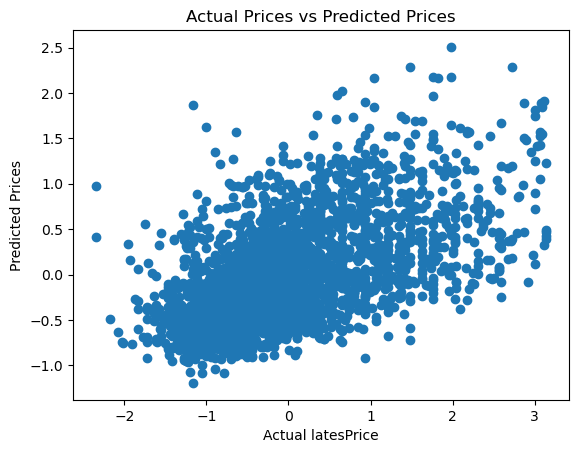

In [46]:
# plotting graph

# Step 9: Visualize the results (optional)
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual latesPrice")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

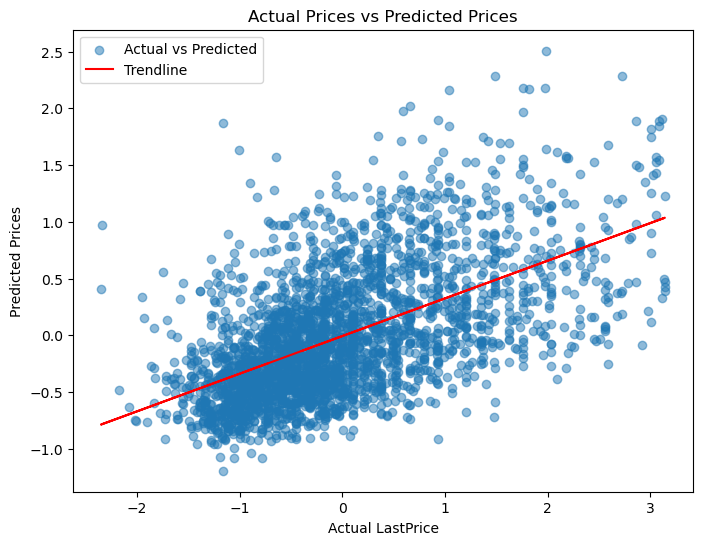

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# source : https://www.geeksforgeeks.org/how-to-create-a-residual-plot-in-python/

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_pred, alpha=0.5, label='Actual vs Predicted')

# Add a trendline or regression line
z = np.polyfit(Y_test, Y_pred, 1)
p = np.poly1d(z)
plt.plot(Y_test, p(Y_test), color='red', label='Trendline')

# Labels
plt.xlabel("Actual LastPrice")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")


plt.legend()
plt.show()


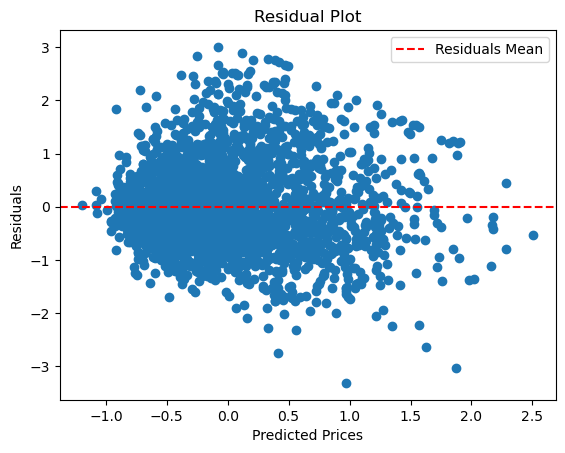

In [48]:
# Residual Plot:
# source : https://www.geeksforgeeks.org/how-to-create-a-residual-plot-in-python/
residuals = Y_test - Y_pred
plt.scatter(Y_pred, residuals)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.axhline(y=0, color='r', linestyle='--', label="Residuals Mean")
plt.title("Residual Plot")
plt.legend()
plt.show()
